### 2.1. Analisying the target

In [1]:
#IMPORTING PANDAS AND MATPLOTLIB
import pandas as pd
import sklearn as sk
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
#CREATING A DATAFRAME FROM THE DATA
df = pd.read_csv('../data/raw/state_of_data_survey_2024.csv')


In [ ]:
#DEFING AND PREPARING THE TARGET VALUE (salarios)

##FINDING THE FEATURE TO TARGET
list(df.columns)
df['2.h_faixa_salarial'].value_counts().sort_values()

novas_categorias = {
    'de R$ 8.001/mês a R$ 12.000/mês': 'de R$ 8.001/mês a R$ 12.000/mês',
    'de R$ 12.001/mês a R$ 16.000/mês': 'de R$ 12.001/mês a R$ 20.000/mês',
    'de R$ 6.001/mês a R$ 8.000/mês': 'de R$ 6.001/mês a R$ 8.000/mês',
    'de R$ 4.001/mês a R$ 6.000/mês': 'de 3.001/mês a R$ 6.000/mês',
    'de R$ 16.001/mês a R$ 20.000/mês': 'de R$ 12.001/mês a R$ 20.000/mês',
    'de R$ 3.001/mês a R$ 4.000/mês': 'de 3.001/mês a R$ 6.000/mês',
    'de R$ 20.001/mês a R$ 25.000/mês': 'acima de R$ 20.000/mês',
    'de R$ 2.001/mês a R$ 3.000/mês': 'até R$ 3.000/mês',
    'de R$ 25.001/mês a R$ 30.000/mês': 'acima de R$ 20.000/mês',
    'de R$ 30.001/mês a R$ 40.000/mês': 'acima de R$ 20.000/mês',
    'de R$ 1.001/mês a R$ 2.000/mês': 'até R$ 3.000/mês',
    'Acima de R$ 40.001/mês': 'acima de R$ 20.000/mês',
    'Menos de R$ 1.000/mês': 'até R$ 3.000/mês'
}

df['categorias_target'] = df['2.h_faixa_salarial'].map(novas_categorias)
df = df[df['categorias_target'].isna() == False]





In [ ]:
df['categorias_target'].isna().sum()

In [ ]:
#LOOKING TO THE GRAFIC

df['2.h_faixa_salarial'].hist(orientation='horizontal',
                              histtype='bar')

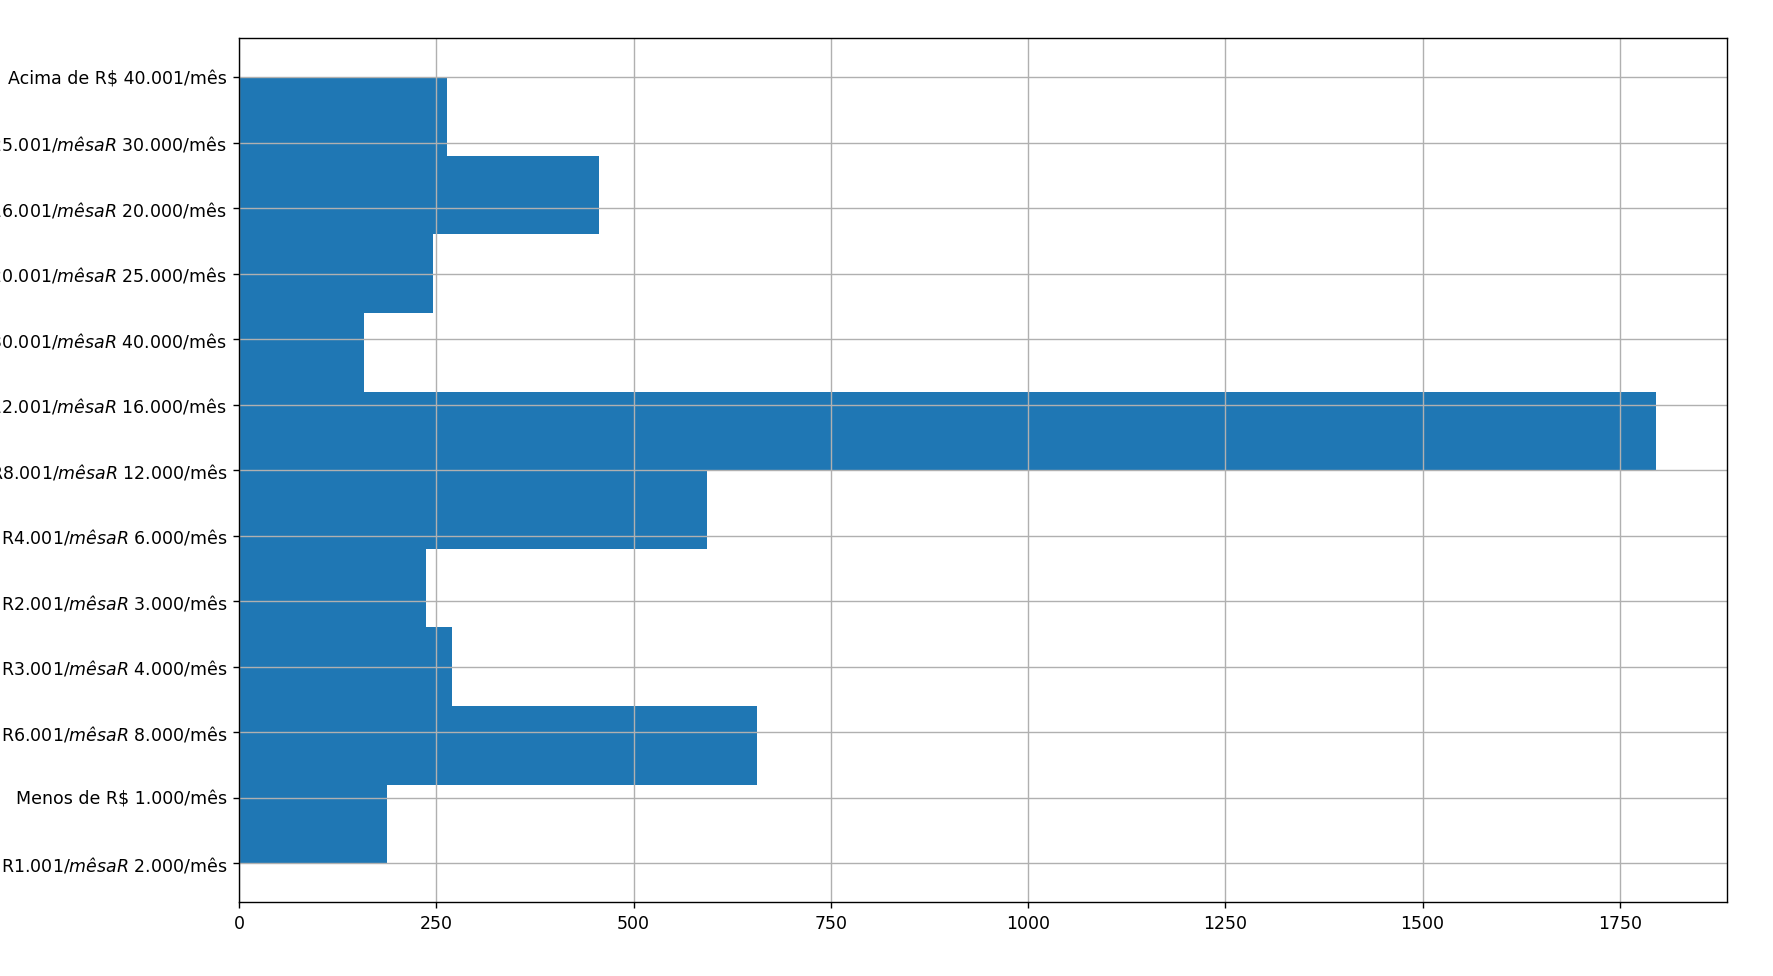

## 2.2. Making the target numeric

I want to make a regressor model (that predicts a numeric value), so i prefer get the mean value of each category.

In [ ]:
categoria_para_valor = {
    'de R$ 8.001/mês a R$ 12.000/mês': 10000,
    'de R$ 12.001/mês a R$ 16.000/mês': 14000,
    'de R$ 6.001/mês a R$ 8.000/mês': 7000,
    'de R$ 4.001/mês a R$ 6.000/mês': 5000,
    'de R$ 16.001/mês a R$ 20.000/mês': 18000,
    'de R$ 3.001/mês a R$ 4.000/mês': 3500,
    'de R$ 20.001/mês a R$ 25.000/mês': 22500,
    'de R$ 2.001/mês a R$ 3.000/mês': 2500,
    'de R$ 25.001/mês a R$ 30.000/mês': 27500,
    'de R$ 30.001/mês a R$ 40.000/mês': 35000,
    'de R$ 1.001/mês a R$ 2.000/mês': 1500,
    'Acima de R$ 40.001/mês': 40500,
    'Menos de R$ 1.000/mês': 500
}

df['salario_medio_por_faixas'] = df['2.h_faixa_salarial'].map(categoria_para_valor)

I also remove all the lines that the target value is NaN

*Why i didn't replace the NaN by other values?*
- I prefer just removing them, because try to replace this values would create unreal target values, what would make my model worse than without this ( in this case, less lines of data don't mean a worse model itself )

In [ ]:
df = df.dropna(subset=['salario_medio_por_faixas'])
df['salario_medio_por_faixas'].isna().sum()

#CHECKING HOW IT LOOKS LIKE
df['salario_medio_por_faixas'].value_counts().sort_index().plot(kind='bar')

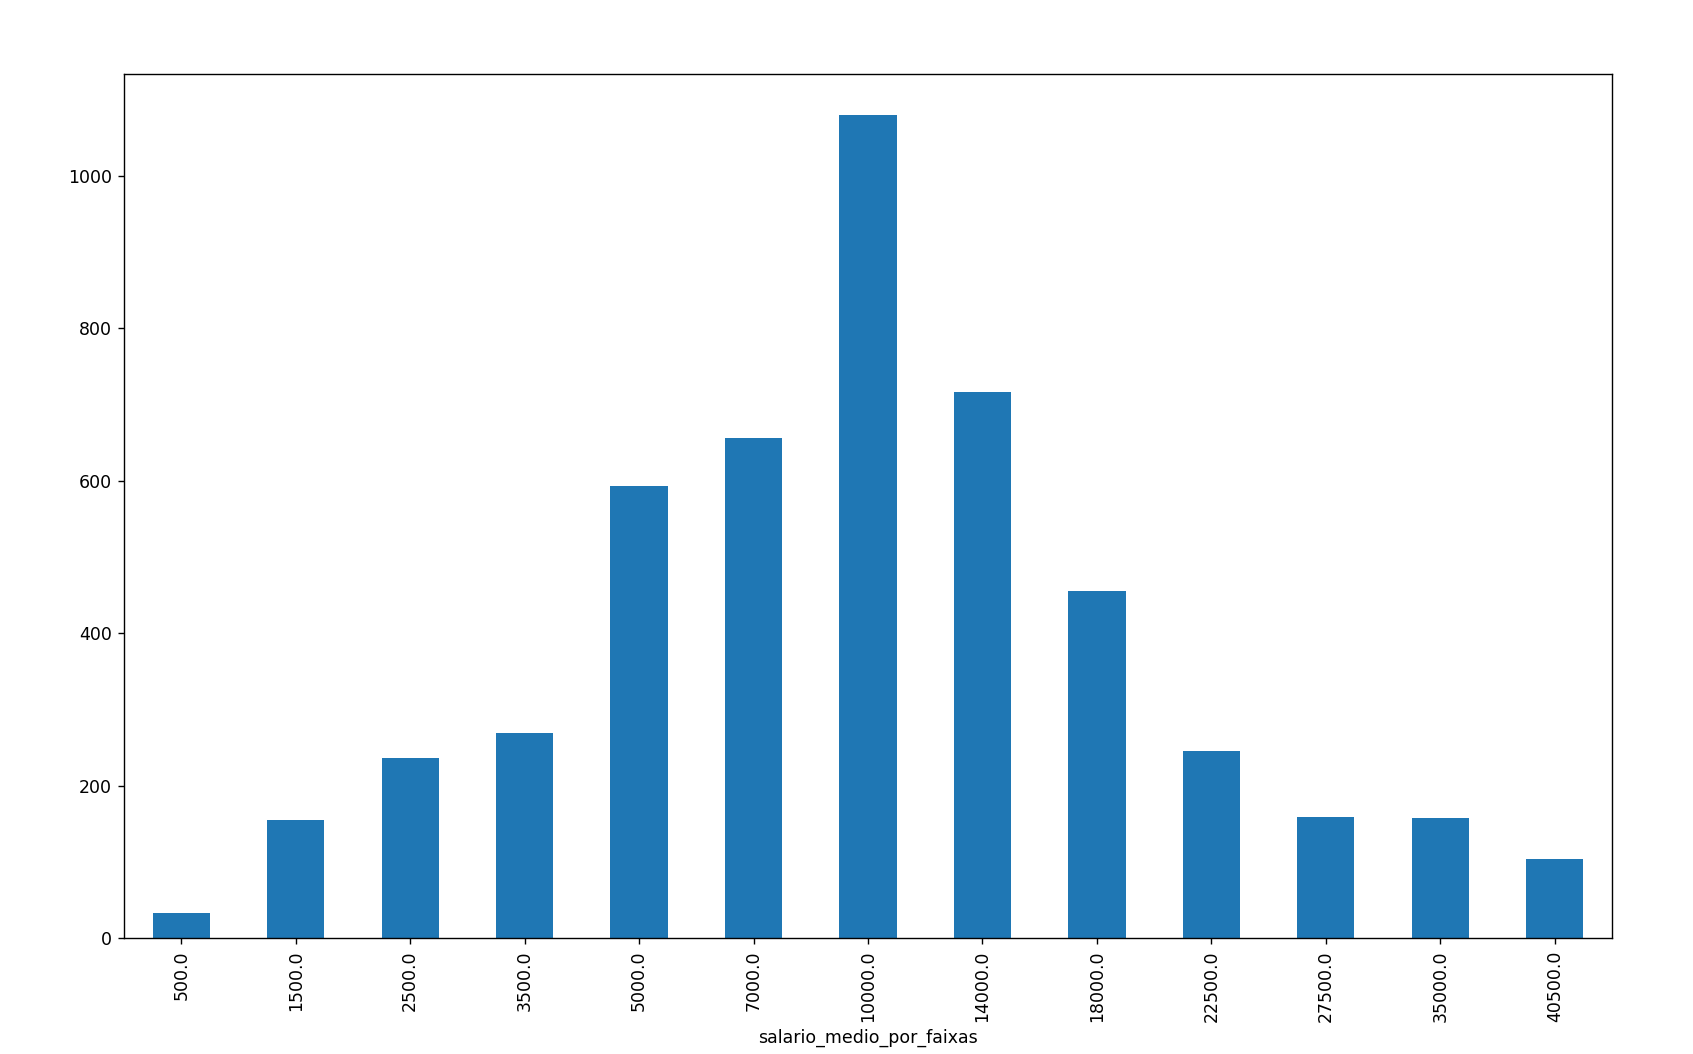

## 2.3. pré-filtering

Getting out features that obviusly is bad for my porpouse

In [ ]:
df['4.d_linguagem_de_programacao_(dia_a_dia)'].value_counts()

In [ ]:
df['1.h_pais_onde_mora'].value_counts()

In [ ]:
df['1.i.1_uf_onde_mora'].value_counts() #mais fácil de lidar

Removendo linhas com vive_em_brasil == False, pois quero centralizar essa pesquisa para pessoas que moram no território brasileiro e ao analisar a coluna '1.h_pais_onde_mora', percebi que os dados não iriam auxiliar no projeto. Além de que a mudança na forma de pagamento pode tornar o projeto tendencioso.

In [ ]:
df = df[df['1.g_vive_no_brasil']] # df['1.g_vive_no_brasil'] == True


In [ ]:
teste_filtro_por_db = [ 
'4.g.1_MySQL',
'4.g.2_Oracle',
'4.g.3_SQL SERVER',
'4.g.4_Amazon Aurora ou RDS',
'4.g.5_DynamoDB',
'4.g.6_CoachDB',
'4.g.7_Cassandra',
'4.g.8_MongoDB',
'4.g.9_MariaDB',
'4.g.10_Datomic',
'4.g.12_PostgreSQL',
'4.g.13_ElasticSearch',
'4.g.15_Microsoft Access',
'4.g.16_SQLite',
'4.g.17_Sybase',
'4.g.18_Firebase',
'4.g.19_Vertica',
'4.g.20_Redis',
'4.g.21_Neo4J',
'4.g.22_Google BigQuery',
'4.g.23_Google Firestore',
'4.g.24_Amazon Redshift',
'4.g.25_Amazon Athena',
'4.g.26_Snowflake',
'4.g.27_Databricks',
'4.g.28_HBase',
'4.g.29_Presto',
'4.g.30_Splunk',
'4.g.31_SAP HANA',
'4.g.32_Hive',
'4.g.33_Firebird',

]

df[teste_filtro_por_db].sum().sort_values(ascending=True).plot(kind="barh", figsize=(8, 10))


### banco de dados escolhidos 

O gráfico mostra que 6 bancos concentram a maioria do uso, com queda acentuada depois de Oracle — o que motiva o corte em top-6.

- 4.g.2_Oracle                   627.0
- 4.g.1_MySQL                    816.0
- 4.g.22_Google BigQuery         920.0
- 4.g.3_SQL SERVER              1022.0
- 4.g.27_Databricks             1089.0
- 4.g.12_PostgreSQL             1098.0

In [ ]:
teste_filtro_por_cloud = [ 
'4.h.1_Amazon Web Services (AWS)',
'4.h.2_Google Cloud (GCP)',
'4.h.3_Azure (Microsoft)',
'4.h.4_Oracle Cloud',
'4.h.5_IBM',
'4.h.6_Servidores On Premise/Não utilizamos Cloud',
'4.h.7_Cloud Própria'
]

df[teste_filtro_por_cloud].sum().sort_values(ascending=True)


In [ ]:
df['2.g_nivel'].dropna()

In [ ]:
df['2.j_tempo_de_experiencia_em_ti'].value_counts().sort_index()

In [ ]:
selecionado = [
    '1.a_idade',
    '1.d_pcd',
    '1.i.1_uf_onde_mora',
    '1.l_nivel_de_ensino', 
    '1.g_vive_no_brasil',
    '1.m_área_de_formação',
    '2.a_situação_de_trabalho',
    '2.b_setor',
    '2.f_cargo_atual',
    '2.g_nivel',   
    '2.j_tempo_de_experiencia_em_ti',
    '4.d.14_JavaScript',                                      
    '4.d.6_Java',
    '4.d.2_R',                                                
    '4.d.3_Python',                                          
    '4.d.1_SQL',
    '4.g.2_Oracle',           
    '4.g.1_MySQL',           
    '4.g.22_Google BigQuery', 
    '4.g.3_SQL SERVER',       
    '4.g.27_Databricks',      
    '4.g.12_PostgreSQL',
    '4.h.6_Servidores On Premise/Não utilizamos Cloud',
    '4.h.2_Google Cloud (GCP)',
    '4.h.3_Azure (Microsoft)',
    '4.h.1_Amazon Web Services (AWS)',
    'salario_medio_por_faixas'
]

df_tratado = (df[selecionado]
              .rename(columns={
                '1.a_idade': 'idade', 
                '1.d_pcd': 'pcd',
                '1.i.1_uf_onde_mora': 'uf_onde_mora',
                '1.l_nivel_de_ensino': 'nivel_de_ensino', 
                '1.g_vive_no_brasil' : 'vive_no_brasil',
                '1.m_área_de_formação': 'area_formacao',
                '2.a_situação_de_trabalho': 'situacao_trabalho',
                '2.b_setor': 'setor',
                '2.f_cargo_atual': 'cargo_atual',
                '2.g_nivel': 'nivel_senioridade',   
                '2.j_tempo_de_experiencia_em_ti': 'tempo_experiencia',
                '4.d.14_JavaScript': 'JS',                                      
                '4.d.6_Java': 'Java',
                '4.d.2_R': 'R',                                                
                '4.d.3_Python': 'Python',                                          
                '4.d.1_SQL': 'SQL',
                '4.g.2_Oracle': 'Oracle',           
                '4.g.1_MySQL': 'MySQL',           
                '4.g.22_Google BigQuery': 'Google_BigQuery', 
                '4.g.3_SQL SERVER': 'SQL_Server',       
                '4.g.27_Databricks': 'Databricks',      
                '4.g.12_PostgreSQL': 'PostgreSQL',
                '4.h.6_Servidores On Premise/Não utilizamos Cloud': 'nao_utilizamos_cloud',
                '4.h.2_Google Cloud (GCP)': 'Google_cloud',
                '4.h.3_Azure (Microsoft)': 'Azure',
                '4.h.1_Amazon Web Services (AWS)': 'AWS',
                'salario_medio_por_faixas':'salario_target'
                   
})) 

df_tratado

## Dividindo os dados em train/test set

In [ ]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(df_tratado, 
                                       test_size=0.2, 
                                       stratify=df_tratado["salario_target"],
                                       random_state=42)



Gerando copia do train_set para analisar a correlação entre features e o target

In [ ]:
survey_data = train_set.copy()
survey_data


In [ ]:
correaltion = survey_data.corr(numeric_only=True)
correaltion['salario_target'].sort_values(ascending=False)

In [ ]:
survey_data.groupby("nivel_senioridade")["salario_target"].median().sort_values()

In [ ]:
analysis_features = ["cargo_atual","situacao_trabalho","setor","uf_onde_mora",
                     "nivel_de_ensino","area_formacao",'tempo_experiencia']
for an in analysis_features:
    group = survey_data.groupby(an)["salario_target"].median().sort_values()
    print('MÉDIA SALARIAL POR: ', group)
    print('-' * 100)


Vou remover as categorias
- Desempregado e não estou buscando recolocação                         7
- Vivo fora do Brasil e trabalho para empresa de fora do Brasil         4

por serem pouco representativas e introduzir ruído no modelo desnecessáriamente, além disso pois removi anteriormente todas as linhas de pessoas que não moram no Brasil. Logo um ruído desnecessário foi adicionado ao projeto.

In [ ]:
remover = ['Vivo fora do Brasil e trabalho para empresa de fora do Brasil',
                          'Desempregado e não estou buscando recolocação']

survey_data = survey_data[~survey_data['situacao_trabalho'].isin(remover)]
# ~ introduz uma negação


In [ ]:
survey_data.isna().sum().sort_values(ascending=False)

Analisando se todas as 980 são pessoas em comum

In [ ]:
python_bool = survey_data['Python'].isna()

amostragem = ['nivel_senioridade', 'cargo_atual', 'SQL', 'Python']

survey_data.loc[python_bool, amostragem].isna().all(axis=1).sum()

In [ ]:
# Grupo A: sem cargo (os 809)
grupo_a = survey_data["cargo_atual"].isna()

# Grupo B: sem stack MAS com cargo (os 171)
grupo_b = survey_data["Python"].isna() & survey_data["cargo_atual"].notna()

print("=== GRUPO A (sem cargo, 809) ===")
print("Quantos:", grupo_a.sum())
print("Salário mediano:", survey_data.loc[grupo_a, "salario_target"].median())
print("Situação de trabalho:")
print(survey_data.loc[grupo_a, "situacao_trabalho"].value_counts())

print("\n=== GRUPO B (sem stack, com cargo, 171) ===")
print("Quantos:", grupo_b.sum())
print("Salário mediano:", survey_data.loc[grupo_b, "salario_target"].median())
print("Cargos:")
print(survey_data.loc[grupo_b, "cargo_atual"].value_counts().head(10))

In [ ]:
survey_data['nivel_senioridade'].isna().sum()

## Plano de preparação dos dados (pipeline)

TARGET:
- salario_target já convertido (faixa → ponto médio)
- Considerar log-transform (cauda pesada) via TransformedTargetRegressor

FEATURES NUMÉRICAS (idade, tempo_experiencia):
- Imputar NaN (mediana)
- StandardScaler

FEATURES BINÁRIAS (stack: linguagens, bancos, clouds):
- Imputar NaN com 0

FEATURES CATEGÓRICAS (cargo, senioridade, setor, uf, formação, etc.):
- Imputar NaN com "Não informado"
- OneHotEncoder (handle_unknown="ignore")

REMOÇÕES PRÉ-SPLIT (regras de escopo):
- "Vivo fora do Brasil"

## REFAZENDO O TRAIN_SET

In [ ]:
remover = ['Vivo fora do Brasil e trabalho para empresa de fora do Brasil',
                          'Desempregado e não estou buscando recolocação']

df_tratado = df_tratado[~df_tratado['situacao_trabalho'].isin(remover)]
# df_tratado.drop(columns='vive_no_brasil', inplace=True)

In [ ]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(df_tratado, 
                                       test_size=0.2, 
                                       stratify=df_tratado["salario_target"],
                                       random_state=42)

SEPARANDO TARGET DAS FEATURES

In [ ]:
y_train = train_set['salario_target'].copy()
X_train = train_set.drop(columns='salario_target')

# DATA CLEANING

Separando as features pro tipos

In [ ]:
# CATEGORIAS
num_list = ['idade']

cat_ordinal_list = ['nivel_de_ensino',
                    'nivel_senioridade',
                    'tempo_experiencia']

cat_one_hot_list = [ 'pcd', 'uf_onde_mora', 
                     'area_formacao', 'situacao_trabalho',
                     'setor', 'cargo_atual']

bin_list = ['JS', 'Java', 'R', 'Python',
       'SQL', 'Oracle', 'MySQL', 'Google_BigQuery', 'SQL_Server', 'Databricks',
       'PostgreSQL', 'nao_utilizamos_cloud', 'Google_cloud', 'Azure', 'AWS']

**ESTRATEGIAS PARA CADA TIPO DE DADO**

- NUMERICO: SimpleImputer -> StandardScaler
- CATEGÓRICO: SimpleImputer -> Encoding

In [ ]:
X_train['nivel_de_ensino'].unique()

In [ ]:
X_train['nivel_senioridade'].unique()

In [ ]:
X_train['tempo_experiencia'].unique()

In [ ]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

#NAO TEM NaN na idade
pipeline_num = make_pipeline(StandardScaler())

pipeline_cat_ordinal = make_pipeline(SimpleImputer(strategy='constant', 
                                           fill_value='Nao Informado'),
                                     OrdinalEncoder(categories=[
                                         ['Prefiro não informar', 'Não tenho graduação formal',
                                          'Estudante de Graduação', 'Graduação/Bacharelado',
                                          'Pós-graduação', 'Mestrado', 'Doutorado ou Phd' ],
                                          ['Nao Informado', 'Júnior', 'Pleno', 'Sênior'],
                                          ['Não tive experiência na área de TI/Engenharia de Software antes de começar a trabalhar na área de dados',
                                           'Menos de 1 ano', 'de 1 a 2 anos','de 3 a 4 anos','de 5 a 6 anos','de 7 a 10 anos','Mais de 10 anos']
                                     ]))

pipeline_cat_one_hot = make_pipeline(SimpleImputer(strategy='constant', 
                                           fill_value='Nao Informado'),
                                     OneHotEncoder(handle_unknown='ignore',
                                                   sparse_output=False))

pipeline_bin = make_pipeline(SimpleImputer(strategy='constant', 
                                          fill_value=0))

GERANDO O COLUMNTRANSFORMER

In [ ]:
preprocessing = ColumnTransformer([
    ("num", pipeline_num, num_list),
    ("cat_ord", pipeline_cat_ordinal, cat_ordinal_list),
    ("cat_one_hot", pipeline_cat_one_hot, cat_one_hot_list),
    ("bin", pipeline_bin, bin_list),
])


In [ ]:
#APLICANDO AO X_TRAIN

X_preprocessing = pd.DataFrame(preprocessing.fit_transform(X_train),
                               columns=preprocessing.get_feature_names_out(),
                               index=X_train.index)

In [ ]:
print(X_preprocessing.shape)
print(X_preprocessing.columns.tolist()[:20])  # primeiros nomes pra inspecionar

## GERANDO PIPELINE COMPLETO PARA TESTES

#### TESTANDO MODELOS PARA PREDIÇÃO E COMPARANDO COM BASELINE

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import cross_val_score

reg_dummy = DummyRegressor(strategy='median')
lin_model = make_pipeline(preprocessing, LinearRegression())
tree_decision_model = make_pipeline(preprocessing, DecisionTreeRegressor())
random_forest_model = make_pipeline(preprocessing, RandomForestRegressor())

select_models = [reg_dummy, lin_model, tree_decision_model, random_forest_model]

for model in select_models:
    cross_val_model = -cross_val_score(model,
                                    X_train,
                                    y_train,
                                    scoring='neg_root_mean_squared_error', 
                                    cv=5)
    print(f"MEDIAN: {cross_val_model.mean():.2f}\nSTANDARD DEVIATION: {cross_val_model.std():.2f}\n")

MODELO ESCOLHIDO FOI: Random Forest (modelo mais promissor no que se refere a fine-tuning, pelo alto número de parametros)

In [ ]:
from sklearn.compose import TransformedTargetRegressor

transform_target = TransformedTargetRegressor(random_forest_model,
                                              func=np.log,
                                              inverse_func=np.exp)

cross_val_model_log = -cross_val_score(transform_target,
                                X_train,
                                y_train,
                                scoring='neg_root_mean_squared_error', 
                                cv=5)
print(cross_val_model_log.mean(), cross_val_model_log.std())

#### DADO IMPORTANTE:

Testei log-transform no target para lidar com a cauda pesada salarial, mas não houve melhora (RMSE 5.604 → 5.628). Combinado com a convergência de modelos distintos para ~5.600, concluo que o erro é limitado pela discretização do target (faixas convertidas em pontos médios), não pela modelagem. O piso de erro é estrutural.

In [ ]:
random_forest_model.fit(X_train, y_train)
feature_importances = random_forest_model.named_steps['randomforestregressor'].feature_importances_
df_feature_importances = pd.DataFrame(feature_importances,
                                      index=preprocessing.get_feature_names_out())
df_feature_importances.sort_values(by=0 ,ascending=False) #by representa a coluna de referência

### CONCLUSÕES IMPORTANTES A PARTIR DESSA ANALISE DE FEATURES IMPORTANCE

1. A senioridade ainda lidera como feature mais importante para determinar o salário do profissional em TI ( contrariando a crença que a stack é mais importante ).


2. Cargo Atual Não informado: DECISÃO DE PROJETO VALIDADA!
    - Antes dessa confirmação haviamos chegado na conclusão de que haviam 890 NaN no cargo atual que implicavam na nulidade do preenchimento das stacks, mas também se enquadravam como um grupo de alto salário. Minha decisão foi deixar esses NaNs e transforma-los em uma categoria chamada "Não Informado" para confirmar se ela também não tinha importancia na qualidade preditiva no meu modelo.
    - Após a ultima analise ela foi elencada como 2º feature mais relevante, logo isso significa que a decisão de criar essa categoria foi validada positivamente.

#### COMPARANDO PREVISÃO E ERROS POR FAIXA SALARIAL

In [ ]:
from sklearn.model_selection import cross_val_predict

predicts_modelo = cross_val_predict(random_forest_model,
                                    X_train,
                                    y_train,
                                    cv=5)



In [ ]:
absolute_error = np.abs(predicts_modelo - y_train)

df_error = pd.DataFrame({
    'predicts_modelo': predicts_modelo,
    'targets_reais': y_train,
'absolute_error': absolute_error
})


df_error.groupby("targets_reais")["absolute_error"].agg(["mean", "count"])

A análise de erros revelou que o modelo de regressão erra pouco nas faixas centrais (~R$ 2.500) mas catastroficamente nas faixas altas (R$ 16.900 de erro na faixa de R$ 40.000+), subestimando sistematicamente salários altos. Isso ocorre porque a regressão 'puxa' previsões em direção à média, falhando em faixas extremas com poucos exemplos. Essa limitação estrutural motivou a reformulação do problema como classificação ordinal, que trata cada faixa como classe e permite técnicas de balanceamento para as faixas raras.

#### APLICANDO NO TEST SET FINAL E VERIFICANDO O DESEMPENHO DO MODELO 

In [ ]:
# separando o test set

y_test = test_set['salario_target'].copy()
X_test = test_set.drop(columns='salario_target')

In [ ]:
from sklearn.metrics import root_mean_squared_error 

random_forest_model.fit(X_train, y_train)
predicts_model = random_forest_model.predict(X_test)

rsme_final = root_mean_squared_error(y_test, predicts_model)
rsme_final